## Electric vehicle brand analysis:

- This dataset provides detailed analytics on electric vehicles (EVs) across various brands, years, and regions. It contains both technical specifications and performance indicators, as well as cost and usage metrics, making it suitable for trend analysis, performance benchmarking, and predictive modeling in the electric vehicle domain.

## Columns: 

- Brand: The manufacturer of the electric vehicle (e.g., Tesla, Nissan, BMW).
- Year: Year of manufacturing of the EV.
- Region: Market/region where the vehicle is used (e.g., Australia).
- Vehicle_Type: Category of the vehicle (e.g., Sedan, Hatchback, SUV, Truck).
- Battery_Capacity_kWh: Total battery capacity in kilowatt-hours (kWh).
- Battery_Health_%: Current health of the battery, expressed as a percentage of its original capacity.
- Charging_Power_kW: Maximum charging power supported by the vehicle.
- Charging_Time_hr: Time required to fully charge the vehicle battery.
- Range_km: Maximum driving range on a full charge (in kilometers).
- Energy_Consumption_kWh_per_100km: Energy consumption efficiency per 100 kilometers.
- Mileage_km: Total distance the vehicle has traveled.
- Avg_Speed_kmh: Average speed of the vehicle.
- Top speed: Maximum speed capability (km/h).
- Acceleration_0_100_kmh_sec: Time taken to accelerate from 0 to 100 km/h (in seconds).
- Electricity_Cost_USD_per_kWh: Cost of electricity per unit used for charging.
- Insurance_Cost_USD: Estimated yearly insurance cost.
- Maintenance_Cost_USD: Estimated yearly maintenance cost.
- Monthly_Charging_Cost_USD: Average monthly charging expenses.
- Resale_Value_USD: Estimated resale value of the vehicle.
- Temperature_C: Operating/environmental temperature.
- Usage_Type: Type of use (e.g., personal, commercial).

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandasql as psql

In [7]:
df = pd.read_excel('electric_vehicle_analytics.xlsx')

In [8]:
df

,Vehicle_ID,Brand,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,...,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD
0,1,Nissan,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,...,233,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483
1,2,Nissan,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,...,221,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287
2,3,Hyundai,2021,North America,SUV,118.5,84.0,677,173.6,0.84,...,138,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023
3,4,Audi,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,...,192,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398
4,5,Tesla,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,...,189,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Mercedes,2021,North America,SUV,57.2,84.0,239,102.2,0.69,...,154,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749
2996,2997,Ford,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,...,243,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080
2997,2998,Kia,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,...,175,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286
2998,2999,Mercedes,2015,North America,Truck,69.4,98.4,336,94.7,0.90,...,185,9.34,-7.6,Commercial,24.95,1843,1905,0.20,780.03,19581


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Vehicle_ID                        3000 non-null   int64  
 1   Brand                             3000 non-null   object 
 2   Year                              3000 non-null   int64  
 3   Region                            3000 non-null   object 
 4   Vehicle_Type                      3000 non-null   object 
 5   Battery_Capacity_kWh              3000 non-null   float64
 6   Battery_Health_%                  3000 non-null   float64
 7   Range_km                          3000 non-null   int64  
 8   Charging_Power_kW                 3000 non-null   float64
 9   Charging_Time_hr                  3000 non-null   float64
 10  Charge_Cycles                     3000 non-null   int64  
 11  Energy_Consumption_kWh_per_100km  3000 non-null   float64
 12  Mileag

## Goal 1: Battery quality of an electric vehicle brand

In [11]:
df['Average charging cost'] = df['Charging_Power_kW'] / df['Charging_Time_hr']

In [12]:
df

,Vehicle_ID,Brand,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,...,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD,Average charging cost
0,1,Nissan,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,...,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483,187.317073
1,2,Nissan,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,...,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287,582.222222
2,3,Hyundai,2021,North America,SUV,118.5,84.0,677,173.6,0.84,...,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023,206.666667
3,4,Audi,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,...,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398,677.200000
4,5,Tesla,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,...,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033,494.883721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Mercedes,2021,North America,SUV,57.2,84.0,239,102.2,0.69,...,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749,148.115942
2996,2997,Ford,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,...,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080,217.027027
2997,2998,Kia,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,...,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286,7.070312
2998,2999,Mercedes,2015,North America,Truck,69.4,98.4,336,94.7,0.90,...,9.34,-7.6,Commercial,24.95,1843,1905,0.20,780.03,19581,105.222222


In [13]:
df['Average charging cost'] = df['Average charging cost'].round(1)

In [14]:
df

,Vehicle_ID,Brand,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,...,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD,Average charging cost
0,1,Nissan,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,...,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483,187.3
1,2,Nissan,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,...,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287,582.2
2,3,Hyundai,2021,North America,SUV,118.5,84.0,677,173.6,0.84,...,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023,206.7
3,4,Audi,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,...,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398,677.2
4,5,Tesla,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,...,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033,494.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Mercedes,2021,North America,SUV,57.2,84.0,239,102.2,0.69,...,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749,148.1
2996,2997,Ford,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,...,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080,217.0
2997,2998,Kia,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,...,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286,7.1
2998,2999,Mercedes,2015,North America,Truck,69.4,98.4,336,94.7,0.90,...,9.34,-7.6,Commercial,24.95,1843,1905,0.20,780.03,19581,105.2


In [15]:
Battery = df.groupby('Brand')[['Battery_Health_%', 'Battery_Capacity_kWh', 'Monthly_Charging_Cost_USD', 'Average charging cost']].mean().round(1).reset_index()

In [16]:
Battery

,Brand,Battery_Health_%,Battery_Capacity_kWh,Monthly_Charging_Cost_USD,Average charging cost
0,Audi,84.0,75.5,390.9,271.8
1,BMW,85.3,77.6,421.6,255.3
2,Chevrolet,85.2,74.9,430.6,258.4
3,Ford,85.3,76.0,393.8,263.4
4,Hyundai,85.1,76.1,440.0,297.8
5,Kia,84.7,72.7,389.6,258.1
6,Mercedes,85.2,75.8,408.6,279.9
7,Nissan,85.1,73.4,428.9,281.5
8,Tesla,85.9,73.9,432.5,276.7
9,Volkswagen,84.3,72.1,450.7,285.5


In [17]:
Battery_health = Battery[['Brand', 'Battery_Health_%']].sort_values(by = 'Battery_Health_%', ascending = False)

In [18]:
Battery_health

,Brand,Battery_Health_%
8,Tesla,85.9
1,BMW,85.3
3,Ford,85.3
2,Chevrolet,85.2
6,Mercedes,85.2
4,Hyundai,85.1
7,Nissan,85.1
5,Kia,84.7
9,Volkswagen,84.3
0,Audi,84.0


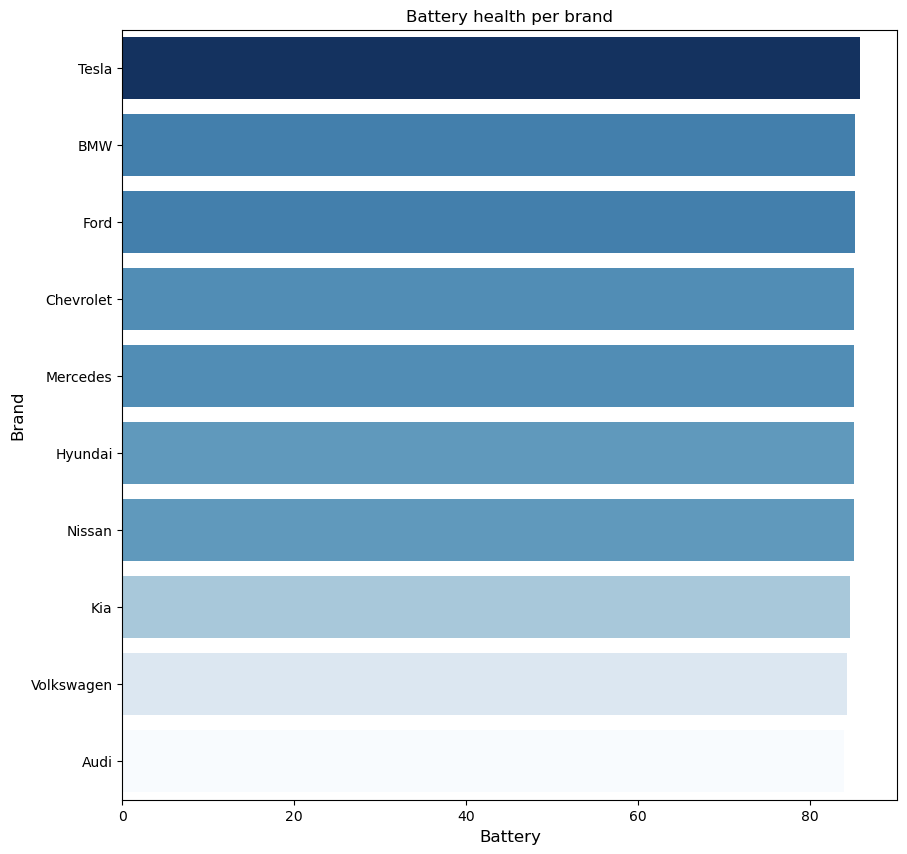

In [19]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Battery_health, y = Battery_health['Brand'], x = Battery_health['Battery_Health_%'], 
           palette = 'Blues', hue = 'Battery_Health_%')
plt.xlabel('Battery', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Battery health per brand')
plt.show()

## Insights:
- Tesla leads in having batteries with the most power, showing superior battery performance.
- followed by a close rate: BMW, Ford, Chevrolet, Mercedes, Hyundai and Nissan, indicating strong battery performance.
- followed by a lower rate: Kia, indicating weak battery performance.
- Volkswagen and Audi have the weakest car batteries.
## Conclusions: 
- Tesla is the first car brand to make electric cars a trend having the most reliable batteries.
- Most electric car brands' batteries performance are high, which show the growth of the electric car market.

## Goal 2: Battery capcity: How much power can a single battery carry?

In [22]:
Battery_capacity = Battery[['Brand', 'Battery_Capacity_kWh']].sort_values(by = 'Battery_Capacity_kWh', ascending = False)

In [23]:
Battery_capacity

,Brand,Battery_Capacity_kWh
1,BMW,77.6
4,Hyundai,76.1
3,Ford,76.0
6,Mercedes,75.8
0,Audi,75.5
2,Chevrolet,74.9
8,Tesla,73.9
7,Nissan,73.4
5,Kia,72.7
9,Volkswagen,72.1


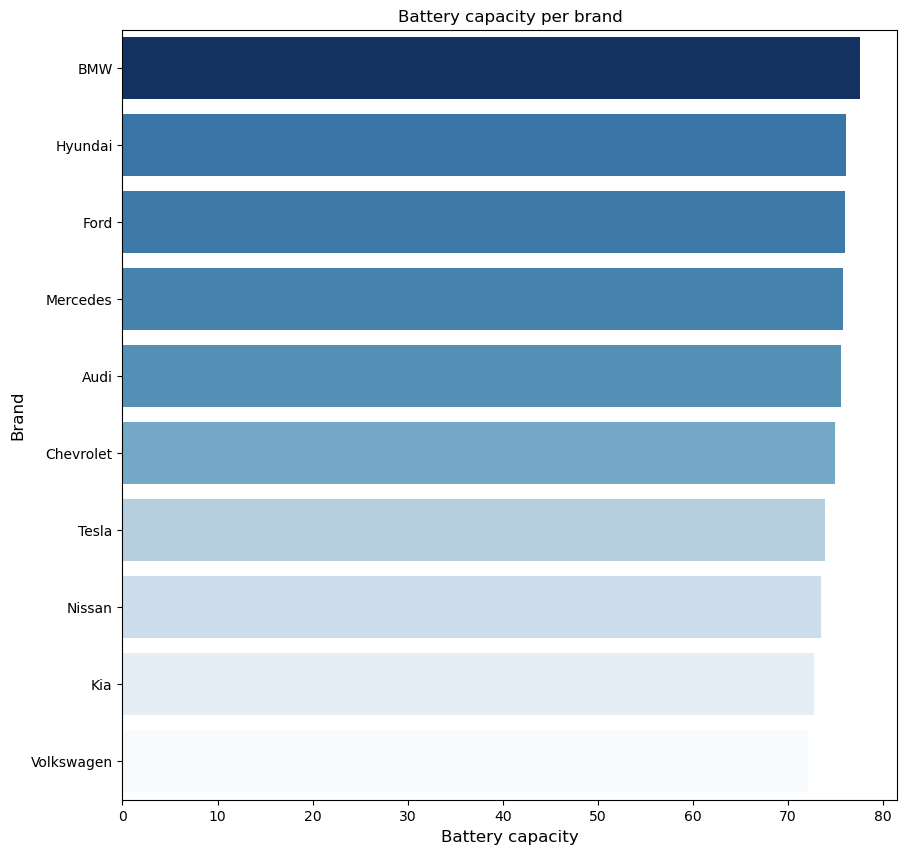

In [24]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Battery_capacity, y = Battery_capacity['Brand'], x = Battery_capacity['Battery_Capacity_kWh'], 
           palette = 'Blues', hue = 'Battery_Capacity_kWh')
plt.xlabel('Battery capacity', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Battery capacity per brand')
plt.show()

## Insights:
- BMW leads in having batteries with the most capcity, indicating big amount of battery power.
- Followed by: Hyundai, Ford, Mercedes, Audi and Chevrolet, indicating slightly big amount of battery power.
- The car brands with the lower amount of battery power are: Tesla (suprsingly) and Nissan.
- followed by: Kia and Volkswagen, which shows that they have the weakest amount of battery power.
## Conclusions:
- Although Tesla is the first electric car brand, its batteries' capacity is small compared to BMW, Hyundai, Ford, Mercedes, Audi and Chervrolet (heavy weight car brands), yet slightly big compared to Nissan, Kia and Volkswagen.
- This shows that Tesla is making prototype vehicles to test their batteries not practical ones for multiple uses.

## Goal 3: Monthly charging cost for battery

In [27]:
Monthly_Charging_Cost = Battery[['Brand', 'Monthly_Charging_Cost_USD']].sort_values(by = 'Monthly_Charging_Cost_USD', ascending = False)

In [28]:
Monthly_Charging_Cost

,Brand,Monthly_Charging_Cost_USD
9,Volkswagen,450.7
4,Hyundai,440.0
8,Tesla,432.5
2,Chevrolet,430.6
7,Nissan,428.9
1,BMW,421.6
6,Mercedes,408.6
3,Ford,393.8
0,Audi,390.9
5,Kia,389.6


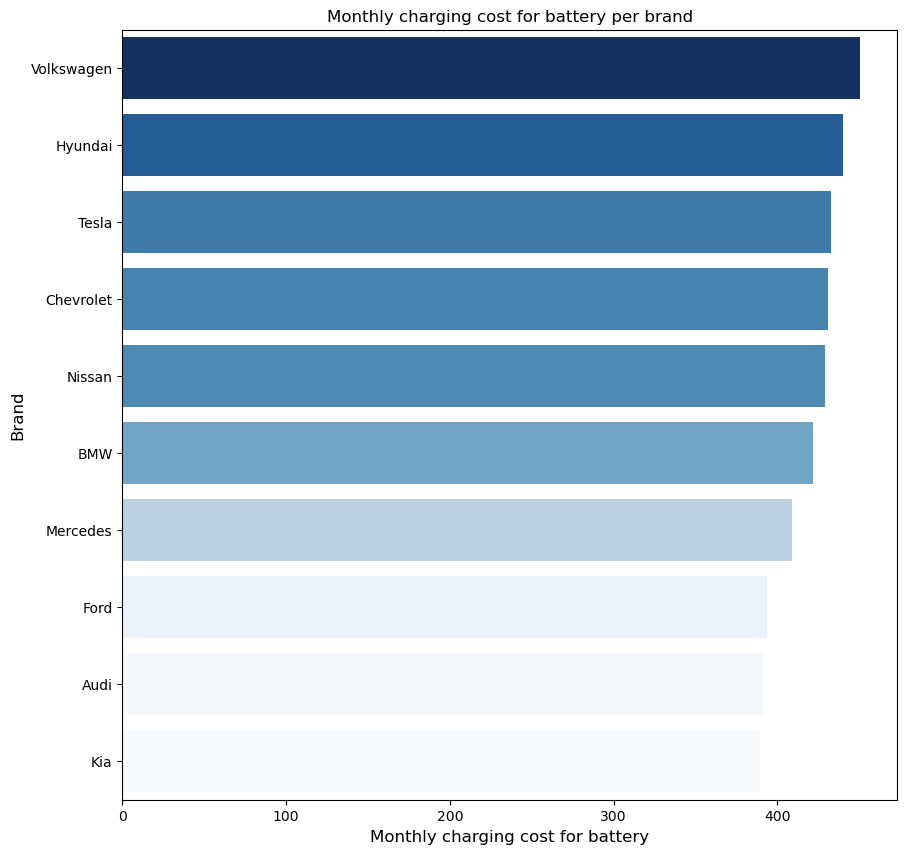

In [29]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Monthly_Charging_Cost, y = Monthly_Charging_Cost['Brand'], x = Monthly_Charging_Cost['Monthly_Charging_Cost_USD'], 
           palette = 'Blues', hue = 'Monthly_Charging_Cost_USD')
plt.xlabel('Monthly charging cost for battery', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Monthly charging cost for battery per brand')
plt.show()

## Insights:
- Volkswagen's batteries cost the most for charging power per month.
- followed by: Hyundai, Tesla, Chevrolet and Nissan, indicating slightly higher cost for charging battery power per month.
- followed slightly by: BMW , indicating lower cost for charging battery power per month but higher than Mercedes, Ford, Audi and Kia.
## Conclusions:
- Monthly charging costs vary significantly across brands, likely reflecting differences in battery size, efficiency, and electricity consumption.
- Ford, Audi and Kia provide more economical charging vehicles for everyday use.
- Tesla costs the most for charging batteries per month since it is the pioneer for electric vehicles.

## Goal 4: Average charging cost for battery

In [32]:
Average_charging_cost = Battery[['Brand', 'Average charging cost']].sort_values(by = 'Average charging cost', ascending = False)

In [33]:
Average_charging_cost

,Brand,Average charging cost
4,Hyundai,297.8
9,Volkswagen,285.5
7,Nissan,281.5
6,Mercedes,279.9
8,Tesla,276.7
0,Audi,271.8
3,Ford,263.4
2,Chevrolet,258.4
5,Kia,258.1
1,BMW,255.3


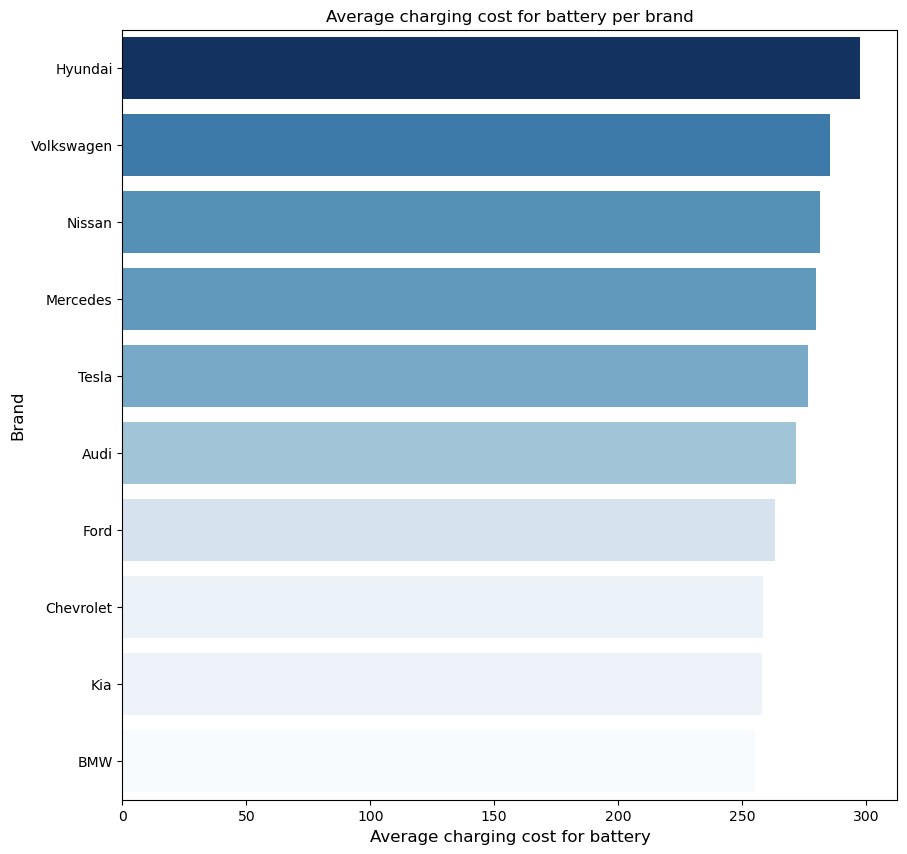

In [34]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Average_charging_cost, y = Average_charging_cost['Brand'], x = Average_charging_cost['Average charging cost'], 
           palette = 'Blues', hue = 'Average charging cost')
plt.xlabel('Average charging cost for battery', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average charging cost for battery per brand')
plt.show()

## Insights:
- Hyundai has the highest average charging cost for battery.
- Followed by: Volkswagen, Nissan, Mercedes, Tesla.
- Audi has lower average charging cost for battery than Hyundai, Volkswagen, Nissan, Mercedes and Tesla.
- But Audi has higher average charging cost for battery than Ford, Chevrolet, Kia and BMW.
## Conclusions:
- Charging costs vary significantly across brands.
- Hyundai and Volkswagen may offer strong battery performance but at a higher operational cost.
- BMW, Kia, Chevrolet, and Ford provide more economical charging, potentially appealing batteries for everyday use for the the middle class.
- Tesla has moderate average charging cost.

## Goal 5: Average accleleration

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Vehicle_ID                        3000 non-null   int64  
 1   Brand                             3000 non-null   object 
 2   Year                              3000 non-null   int64  
 3   Region                            3000 non-null   object 
 4   Vehicle_Type                      3000 non-null   object 
 5   Battery_Capacity_kWh              3000 non-null   float64
 6   Battery_Health_%                  3000 non-null   float64
 7   Range_km                          3000 non-null   int64  
 8   Charging_Power_kW                 3000 non-null   float64
 9   Charging_Time_hr                  3000 non-null   float64
 10  Charge_Cycles                     3000 non-null   int64  
 11  Energy_Consumption_kWh_per_100km  3000 non-null   float64
 12  Mileag

In [38]:
performance = df.groupby('Brand')[['Acceleration_0_100_kmh_sec', 'Mileage_km', 'Avg_Speed_kmh', 'Max_Speed_kmh']].mean().round(1).reset_index()

In [39]:
performance

,Brand,Acceleration_0_100_kmh_sec,Mileage_km,Avg_Speed_kmh,Max_Speed_kmh
0,Audi,6.7,120740.3,68.8,192.8
1,BMW,6.9,127048.6,66.5,189.0
2,Chevrolet,6.7,126802.1,65.2,191.2
3,Ford,6.7,120625.3,64.4,190.1
4,Hyundai,6.8,131762.3,64.3,187.8
5,Kia,6.4,120730.4,65.7,191.5
6,Mercedes,6.8,122345.8,64.7,190.7
7,Nissan,6.8,127948.1,67.1,190.4
8,Tesla,6.6,120153.0,64.9,191.8
9,Volkswagen,6.8,133389.3,65.3,191.6


In [40]:
Average_accleration = performance[['Brand', 'Acceleration_0_100_kmh_sec']].sort_values(by = 'Acceleration_0_100_kmh_sec', ascending = False)

In [41]:
Average_accleration

,Brand,Acceleration_0_100_kmh_sec
1,BMW,6.9
4,Hyundai,6.8
6,Mercedes,6.8
7,Nissan,6.8
9,Volkswagen,6.8
0,Audi,6.7
2,Chevrolet,6.7
3,Ford,6.7
8,Tesla,6.6
5,Kia,6.4


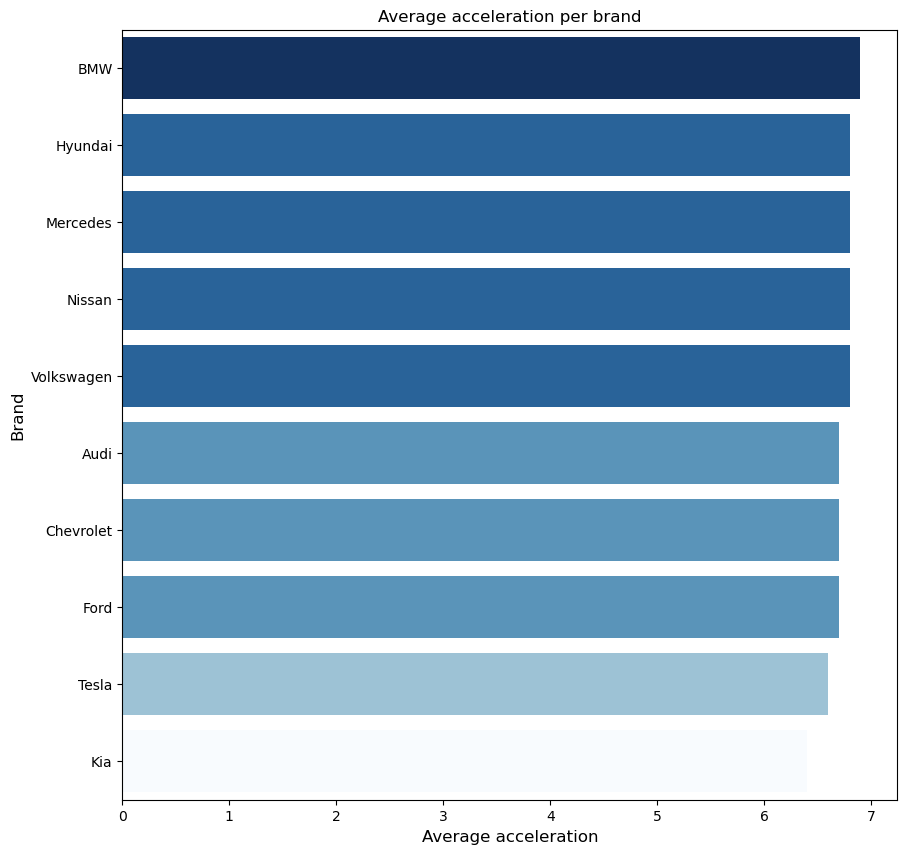

In [86]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Average_accleration, y = Average_accleration['Brand'], x = Average_accleration['Acceleration_0_100_kmh_sec'], 
           palette = 'Blues', hue = 'Acceleration_0_100_kmh_sec')
plt.xlabel('Average acceleration', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average acceleration per brand')
plt.show()

## Conclusions:
- All electric car brands makes vehicles with slightly the same average accleration with BMW taking the lead.
- Tesla and Kia have lower average acceleration.

## Goal 6: Average distance (mileage)

In [76]:
Average_mileage = performance[['Brand', 'Mileage_km']].sort_values(by = 'Mileage_km', ascending = False)

In [78]:
Average_mileage

,Brand,Mileage_km
9,Volkswagen,133389.3
4,Hyundai,131762.3
7,Nissan,127948.1
1,BMW,127048.6
2,Chevrolet,126802.1
6,Mercedes,122345.8
0,Audi,120740.3
5,Kia,120730.4
3,Ford,120625.3
8,Tesla,120153.0


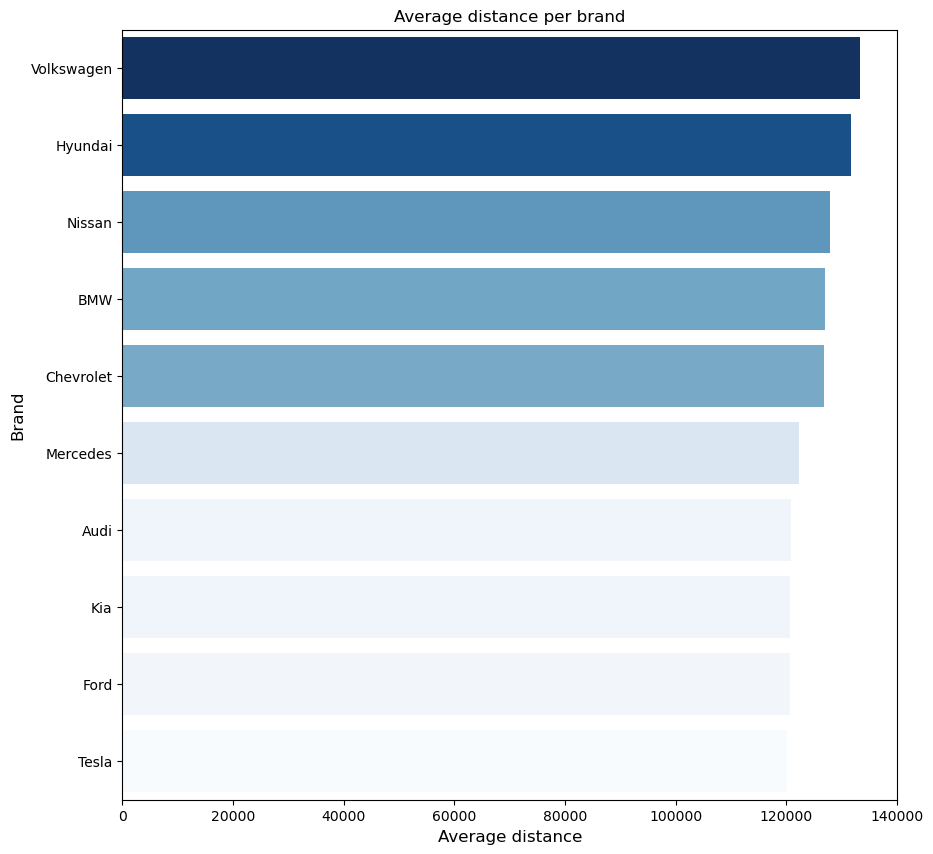

In [88]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Average_mileage, y = Average_mileage['Brand'], x = Average_mileage['Mileage_km'], 
           palette = 'Blues', hue = 'Mileage_km')
plt.xlabel('Average distance', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average distance per brand')
plt.show()

## Insights:
- Volkswagen and Hyundai leads in making electric cars with the best average distance.
- Followed by Nissan, BMW and Chevrolet.
- Mercedes, Audi, Kia, Ford and Tesla make electric with the lowest average distance.
## Conclusions:
- Volkswagen, Hyundai, Nissan, BMW and Chevrolet make cars with comparable average distance.
- While Tesla: the pioneer of electric cars, make cars with the lowest average distance.

## Goal 7: Average speed

In [92]:
performance

,Brand,Acceleration_0_100_kmh_sec,Mileage_km,Avg_Speed_kmh,Max_Speed_kmh
0,Audi,6.7,120740.3,68.8,192.8
1,BMW,6.9,127048.6,66.5,189.0
2,Chevrolet,6.7,126802.1,65.2,191.2
3,Ford,6.7,120625.3,64.4,190.1
4,Hyundai,6.8,131762.3,64.3,187.8
5,Kia,6.4,120730.4,65.7,191.5
6,Mercedes,6.8,122345.8,64.7,190.7
7,Nissan,6.8,127948.1,67.1,190.4
8,Tesla,6.6,120153.0,64.9,191.8
9,Volkswagen,6.8,133389.3,65.3,191.6


In [94]:
Average_speed = performance[['Brand','Avg_Speed_kmh']].sort_values(by = 'Avg_Speed_kmh', ascending = False)

In [96]:
Average_speed

,Brand,Avg_Speed_kmh
0,Audi,68.8
7,Nissan,67.1
1,BMW,66.5
5,Kia,65.7
9,Volkswagen,65.3
2,Chevrolet,65.2
8,Tesla,64.9
6,Mercedes,64.7
3,Ford,64.4
4,Hyundai,64.3


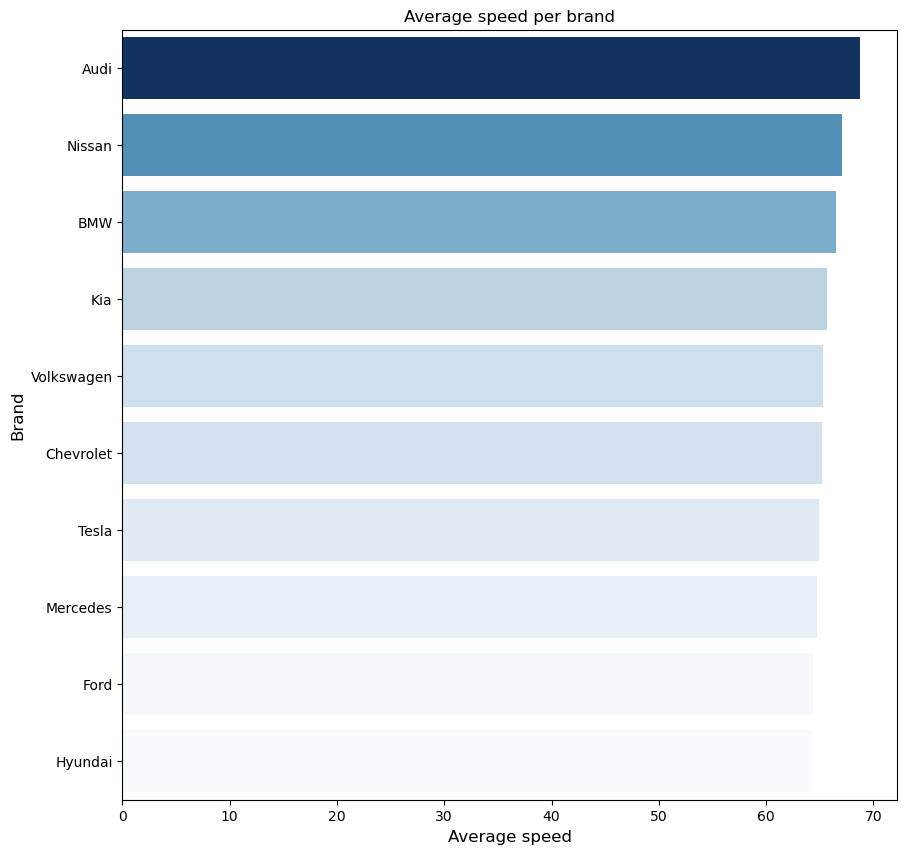

In [98]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Average_speed, y = Average_speed['Brand'], x = Average_speed['Avg_Speed_kmh'], 
           palette = 'Blues', hue = 'Avg_Speed_kmh')
plt.xlabel('Average speed', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average speed per brand')
plt.show()

## Insights:
- Audi leads in making electric cars with the best average speed.
- Followed by a small margin Nissan and BMW.
- Followed by a lower margin Kia, Volkswagen and Chevrolet.
- Tesla, Mercedes, Ford and Hyundai make electric cars with the lowest average speed.
## Conclusions:
- From Audi to BMW: there is a comparable rate of electric cars with the best average speed.
- From Kia onwards: there is a comparable rate of electric cars with the lowest average speed.
- Tesla in particular makes cars with the lowest average speed.

## Goal 8: Average top speed

In [104]:
performance

,Brand,Acceleration_0_100_kmh_sec,Mileage_km,Avg_Speed_kmh,Max_Speed_kmh
0,Audi,6.7,120740.3,68.8,192.8
1,BMW,6.9,127048.6,66.5,189.0
2,Chevrolet,6.7,126802.1,65.2,191.2
3,Ford,6.7,120625.3,64.4,190.1
4,Hyundai,6.8,131762.3,64.3,187.8
5,Kia,6.4,120730.4,65.7,191.5
6,Mercedes,6.8,122345.8,64.7,190.7
7,Nissan,6.8,127948.1,67.1,190.4
8,Tesla,6.6,120153.0,64.9,191.8
9,Volkswagen,6.8,133389.3,65.3,191.6


In [106]:
Average_max_speed = performance[['Brand', 'Max_Speed_kmh']].sort_values(by = 'Max_Speed_kmh', ascending = False)

In [108]:
Average_max_speed

,Brand,Max_Speed_kmh
0,Audi,192.8
8,Tesla,191.8
9,Volkswagen,191.6
5,Kia,191.5
2,Chevrolet,191.2
6,Mercedes,190.7
7,Nissan,190.4
3,Ford,190.1
1,BMW,189.0
4,Hyundai,187.8


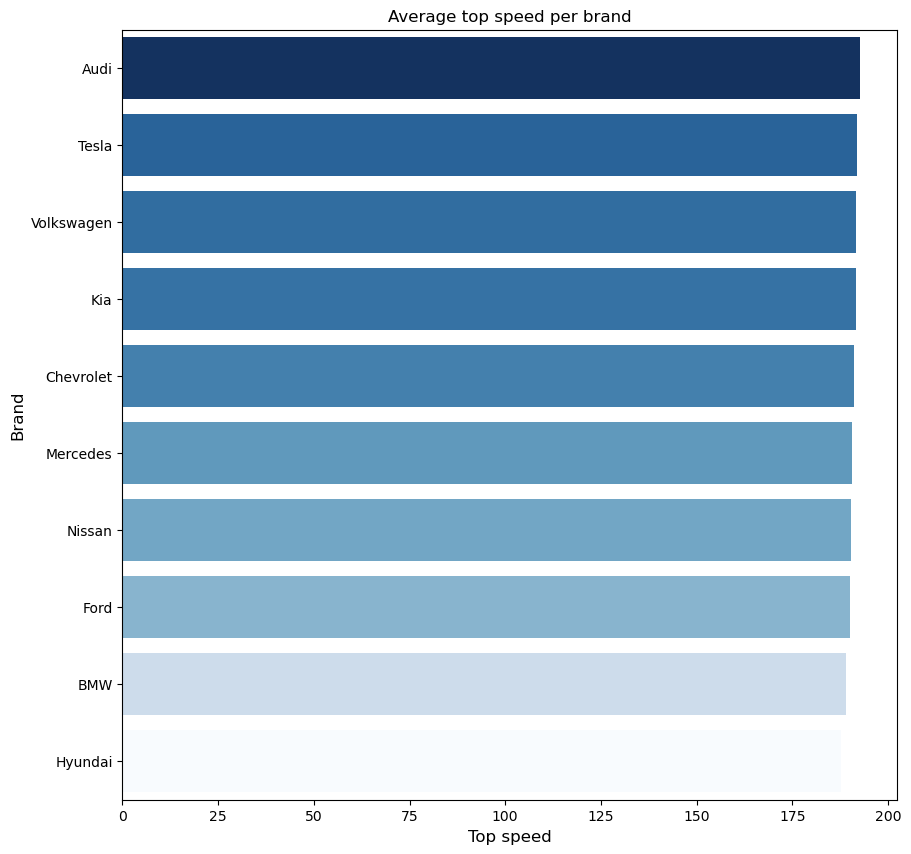

In [110]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Average_max_speed, y = Average_max_speed['Brand'], x = Average_max_speed['Max_Speed_kmh'], 
           palette = 'Blues', hue = 'Max_Speed_kmh')
plt.xlabel('Top speed', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average top speed per brand')
plt.show()

## Insights:
- Audi still leads in making electric cars with the best top speed.
- Followed by a small margin: Tesla (suprsingly), Volkswagen, Kia, Chevrolet, Mercedes, Nissan and Ford.
- Followed by a lower margin: BMW and Hyundai.
## Conclusions:
- From Audi to Ford: there is a consistent rate of electric cars with the most maximum speed.
- Tesla suprsingly follows directly Audi by a small margin.
- BMW and Hyundai make the least maximum speed electric cars.

## Goal 9: Compare brands according to vehicle types and usages.

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Vehicle_ID                        3000 non-null   int64  
 1   Brand                             3000 non-null   object 
 2   Year                              3000 non-null   int64  
 3   Region                            3000 non-null   object 
 4   Vehicle_Type                      3000 non-null   object 
 5   Battery_Capacity_kWh              3000 non-null   float64
 6   Battery_Health_%                  3000 non-null   float64
 7   Range_km                          3000 non-null   int64  
 8   Charging_Power_kW                 3000 non-null   float64
 9   Charging_Time_hr                  3000 non-null   float64
 10  Charge_Cycles                     3000 non-null   int64  
 11  Energy_Consumption_kWh_per_100km  3000 non-null   float64
 12  Mileag

In [121]:
Compare = df[['Brand', 'Vehicle_Type', 'Usage_Type']]

In [123]:
Compare

,Brand,Vehicle_Type,Usage_Type
0,Nissan,SUV,Personal
1,Nissan,Sedan,Personal
2,Hyundai,SUV,Fleet
3,Audi,Hatchback,Fleet
4,Tesla,Truck,Commercial
...,...,...,...
2995,Mercedes,SUV,Personal
2996,Ford,Hatchback,Fleet
2997,Kia,Truck,Fleet
2998,Mercedes,Truck,Commercial


In [172]:
SQL = """SELECT Vehicle_Type, Brand, COUNT(*) AS Number_of_SUVS_produced FROM Compare
WHERE Vehicle_Type = 'SUV'
GROUP BY Brand"""

In [174]:
SUV = psql.sqldf(SQL)

In [176]:
SUV

,Vehicle_Type,Brand,Number_of_SUVS_produced
0,SUV,Audi,89
1,SUV,BMW,82
2,SUV,Chevrolet,83
3,SUV,Ford,73
4,SUV,Hyundai,73
5,SUV,Kia,64
6,SUV,Mercedes,72
7,SUV,Nissan,70
8,SUV,Tesla,70
9,SUV,Volkswagen,89


In [180]:
SUV_sorted = SUV[['Vehicle_Type', 'Brand', 'Number_of_SUVS_produced']].sort_values(by = 'Number_of_SUVS_produced', ascending = False)

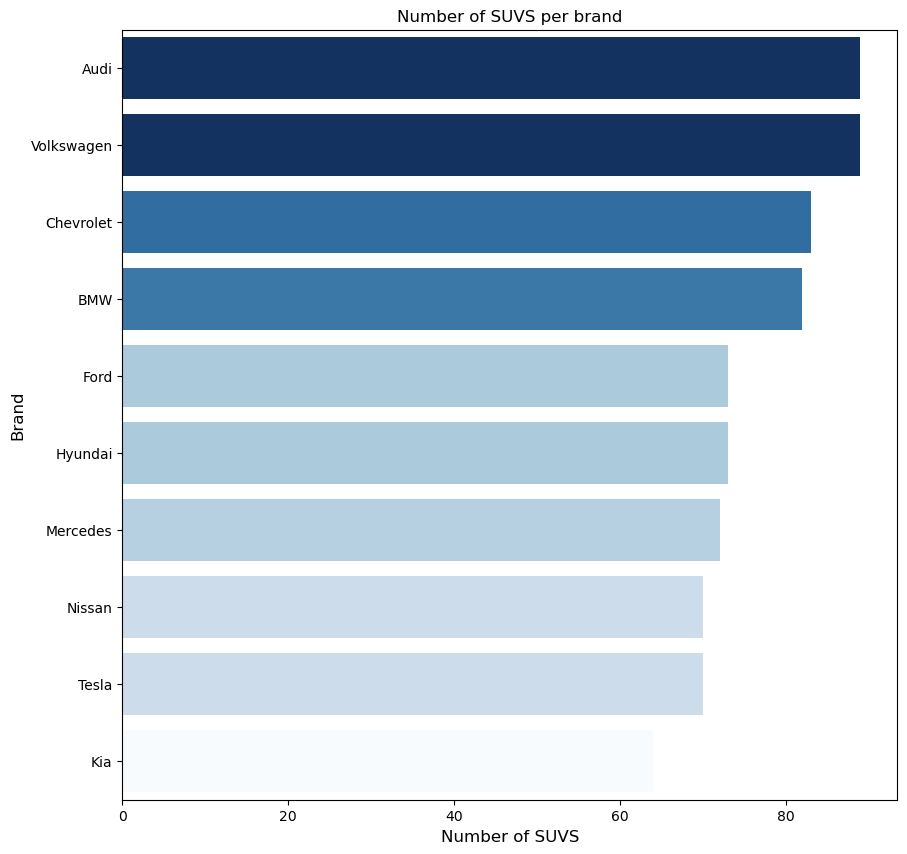

In [182]:
plt.figure(figsize = (10, 10))
sns.barplot(data = SUV_sorted, y = SUV_sorted['Brand'], x = SUV_sorted['Number_of_SUVS_produced'], 
           palette = 'Blues', hue = 'Number_of_SUVS_produced')
plt.xlabel('Number of SUVS', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Number of SUVS per brand')
plt.show()

## Insights:
- Audi and Volkswagen leads in making the most SUVS.
- Followed slightly by Chevrolet and BMW.
- Followed by a large margin: Ford, Hyundai, Mercedes, Nissan and Tesla.
- Kia is the brand with the least number of produced by SUVS.
## Conclusions:
- There is a great amount of SUVS produced in all brands.
- This shows that electric car brands are aiming to make vehicles for everyday use, which is what SUVS specialize at: multi-utility vehicle: from work to travel to comfort to hunt.

In [186]:
SQL1 = """SELECT Vehicle_Type, Brand, COUNT(*) AS Number_of_Sedans_produced FROM Compare
WHERE Vehicle_Type = 'Sedan'
GROUP BY Brand"""

In [188]:
Sedan = psql.sqldf(SQL1)

In [190]:
Sedan

,Vehicle_Type,Brand,Number_of_Sedans_produced
0,Sedan,Audi,63
1,Sedan,BMW,71
2,Sedan,Chevrolet,65
3,Sedan,Ford,67
4,Sedan,Hyundai,84
5,Sedan,Kia,79
6,Sedan,Mercedes,76
7,Sedan,Nissan,78
8,Sedan,Tesla,75
9,Sedan,Volkswagen,80


In [192]:
Sedan_sorted = Sedan[['Vehicle_Type', 'Brand', 'Number_of_Sedans_produced']].sort_values(by = 'Number_of_Sedans_produced', ascending = False)

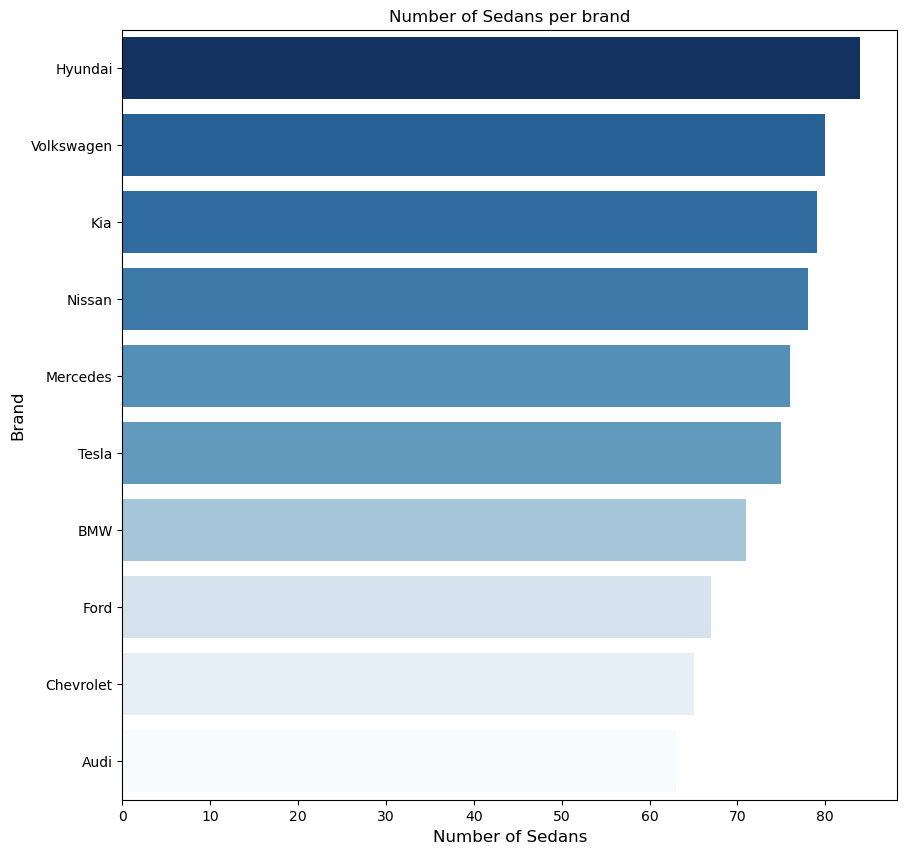

In [196]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Sedan_sorted, y = Sedan_sorted['Brand'], x = Sedan_sorted['Number_of_Sedans_produced'], 
           palette = 'Blues', hue = 'Number_of_Sedans_produced')
plt.xlabel('Number of Sedans', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Number of Sedans per brand')
plt.show()

## Insights:
- Hyundai leads in making the most sedans.
- Followed by a small margin: Volkswagen, Kia, Nissan, Mercedes and Tesla.
- BMW, Ford, Chevrolet and Audi make the least amount of sedans.
## Conclusions:
- There's a great amount of sedans being produced.
- Most car brands produce this type of vehicle.
- This vehicle type targets the middle class which shapes half the car market.

In [199]:
SQL2 = """SELECT Vehicle_Type, Brand, COUNT(*) AS Number_of_Trucks_produced FROM Compare
WHERE Vehicle_Type = 'Truck'
GROUP BY Brand"""

In [201]:
Truck = psql.sqldf(SQL2)

In [203]:
Truck

,Vehicle_Type,Brand,Number_of_Trucks_produced
0,Truck,Audi,66
1,Truck,BMW,82
2,Truck,Chevrolet,80
3,Truck,Ford,77
4,Truck,Hyundai,67
5,Truck,Kia,76
6,Truck,Mercedes,74
7,Truck,Nissan,65
8,Truck,Tesla,65
9,Truck,Volkswagen,72


In [205]:
Truck_sorted = Truck[['Vehicle_Type', 'Brand', 'Number_of_Trucks_produced']].sort_values(by = 'Number_of_Trucks_produced', ascending = False)

In [207]:
Truck_sorted

,Vehicle_Type,Brand,Number_of_Trucks_produced
1,Truck,BMW,82
2,Truck,Chevrolet,80
3,Truck,Ford,77
5,Truck,Kia,76
6,Truck,Mercedes,74
9,Truck,Volkswagen,72
4,Truck,Hyundai,67
0,Truck,Audi,66
7,Truck,Nissan,65
8,Truck,Tesla,65


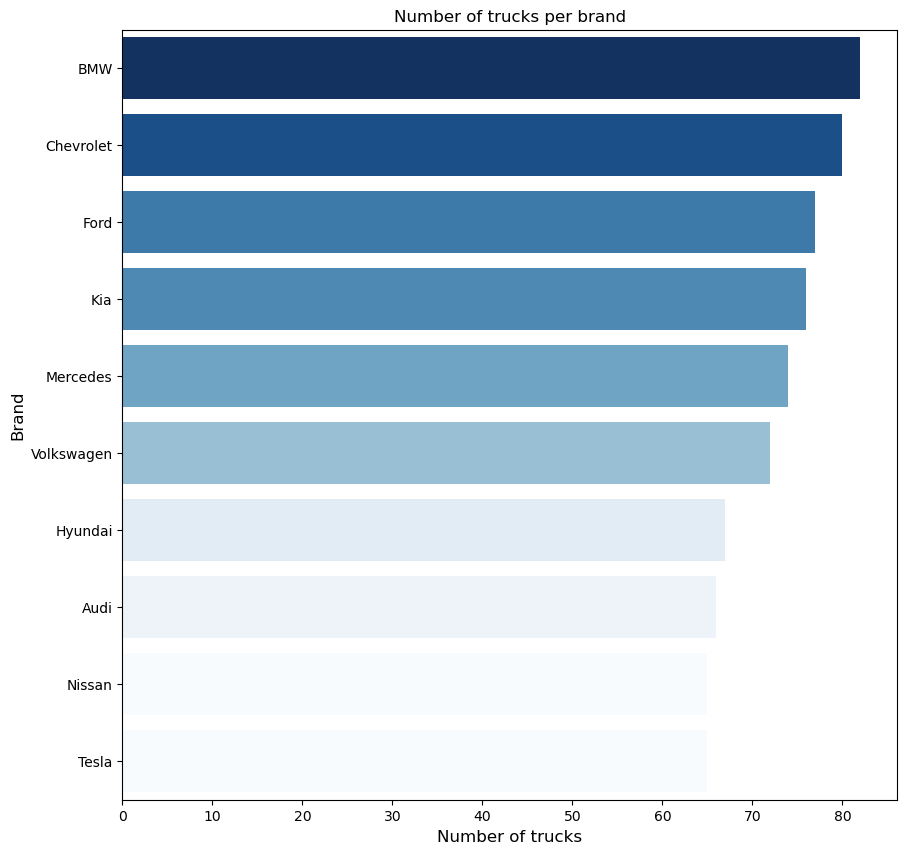

In [209]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Truck_sorted, y = Truck_sorted['Brand'], x = Truck_sorted['Number_of_Trucks_produced'], 
           palette = 'Blues', hue = 'Number_of_Trucks_produced')
plt.xlabel('Number of trucks', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Number of trucks per brand')
plt.show()

## Insights:
- BMW leads in making the most trucks.
- Followed by a large margin: Chevrolet, Ford, Kia, Mercedes and Volkswagen.
- Followed by a lower margin: Hyundai, Audi, Nissan and Tesla.
## Conclusions:
- Despite being the pioneer of electric cars, Tesla makes the least amount of trucks.
- From BMW to Volkswagen: there's a great number of trucks used.

In [214]:
Compare

,Brand,Vehicle_Type,Usage_Type
0,Nissan,SUV,Personal
1,Nissan,Sedan,Personal
2,Hyundai,SUV,Fleet
3,Audi,Hatchback,Fleet
4,Tesla,Truck,Commercial
...,...,...,...
2995,Mercedes,SUV,Personal
2996,Ford,Hatchback,Fleet
2997,Kia,Truck,Fleet
2998,Mercedes,Truck,Commercial


In [216]:
SQL3 = """SELECT Vehicle_Type, Brand, COUNT(*) AS Number_of_Hatchbacks_produced FROM Compare
WHERE Vehicle_Type = 'Hatchback'
GROUP BY Brand"""

In [218]:
Hatchback = psql.sqldf(SQL3)

In [220]:
Hatchback

,Vehicle_Type,Brand,Number_of_Hatchbacks_produced
0,Hatchback,Audi,71
1,Hatchback,BMW,76
2,Hatchback,Chevrolet,80
3,Hatchback,Ford,106
4,Hatchback,Hyundai,73
5,Hatchback,Kia,67
6,Hatchback,Mercedes,71
7,Hatchback,Nissan,85
8,Hatchback,Tesla,77
9,Hatchback,Volkswagen,67


In [222]:
Hatchback_sorted = Hatchback[['Vehicle_Type', 'Brand', 'Number_of_Hatchbacks_produced']].sort_values(by = 'Number_of_Hatchbacks_produced', ascending = False)

In [224]:
Hatchback_sorted

,Vehicle_Type,Brand,Number_of_Hatchbacks_produced
3,Hatchback,Ford,106
7,Hatchback,Nissan,85
2,Hatchback,Chevrolet,80
8,Hatchback,Tesla,77
1,Hatchback,BMW,76
4,Hatchback,Hyundai,73
0,Hatchback,Audi,71
6,Hatchback,Mercedes,71
5,Hatchback,Kia,67
9,Hatchback,Volkswagen,67


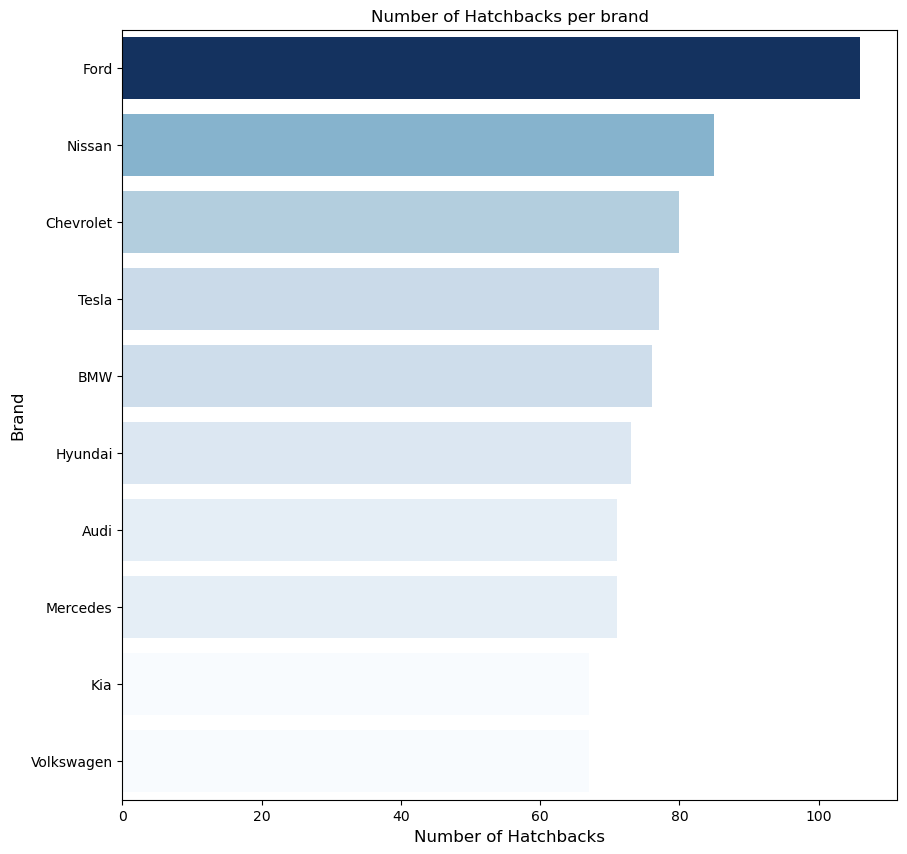

In [226]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Hatchback_sorted, y = Hatchback_sorted['Brand'], x = Hatchback_sorted['Number_of_Hatchbacks_produced'], 
           palette = 'Blues', hue = 'Number_of_Hatchbacks_produced')
plt.xlabel('Number of Hatchbacks', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Number of Hatchbacks per brand')
plt.show()

## Insights:
- Ford leads in making the most hatchback cars.
- Followed by a large margin: Nissan, Chevrolet, Tesla, BMW, Hyundai, Audi and Mercedes.
- Kia and Volkswagen make the least amount of hatchbacks.
## Conclusions:
- Hatchbacks is the vehicle type with the least amount of vehicles produced.
- Only one brand (Ford) makes the most amount of hatchbacks.
- Other brands make small amounts of this vehicle type.

In [229]:
Compare

,Brand,Vehicle_Type,Usage_Type
0,Nissan,SUV,Personal
1,Nissan,Sedan,Personal
2,Hyundai,SUV,Fleet
3,Audi,Hatchback,Fleet
4,Tesla,Truck,Commercial
...,...,...,...
2995,Mercedes,SUV,Personal
2996,Ford,Hatchback,Fleet
2997,Kia,Truck,Fleet
2998,Mercedes,Truck,Commercial


In [259]:
Personal = Compare.loc[Compare['Usage_Type'] == 'Personal', ['Brand', 'Usage_Type']]

In [261]:
Personal

,Brand,Usage_Type
0,Nissan,Personal
1,Nissan,Personal
8,Mercedes,Personal
9,Hyundai,Personal
13,Audi,Personal
...,...,...
2983,Mercedes,Personal
2989,BMW,Personal
2991,Ford,Personal
2995,Mercedes,Personal


In [269]:
Personal1 = Personal.groupby('Brand')['Usage_Type'].count().reset_index()

In [271]:
Personal1

,Brand,Usage_Type
0,Audi,102
1,BMW,100
2,Chevrolet,101
3,Ford,104
4,Hyundai,105
5,Kia,92
6,Mercedes,97
7,Nissan,101
8,Tesla,104
9,Volkswagen,114


In [273]:
Personal_sort = Personal1.sort_values(by = 'Usage_Type', ascending = False)

In [275]:
Personal_sort

,Brand,Usage_Type
9,Volkswagen,114
4,Hyundai,105
3,Ford,104
8,Tesla,104
0,Audi,102
2,Chevrolet,101
7,Nissan,101
1,BMW,100
6,Mercedes,97
5,Kia,92


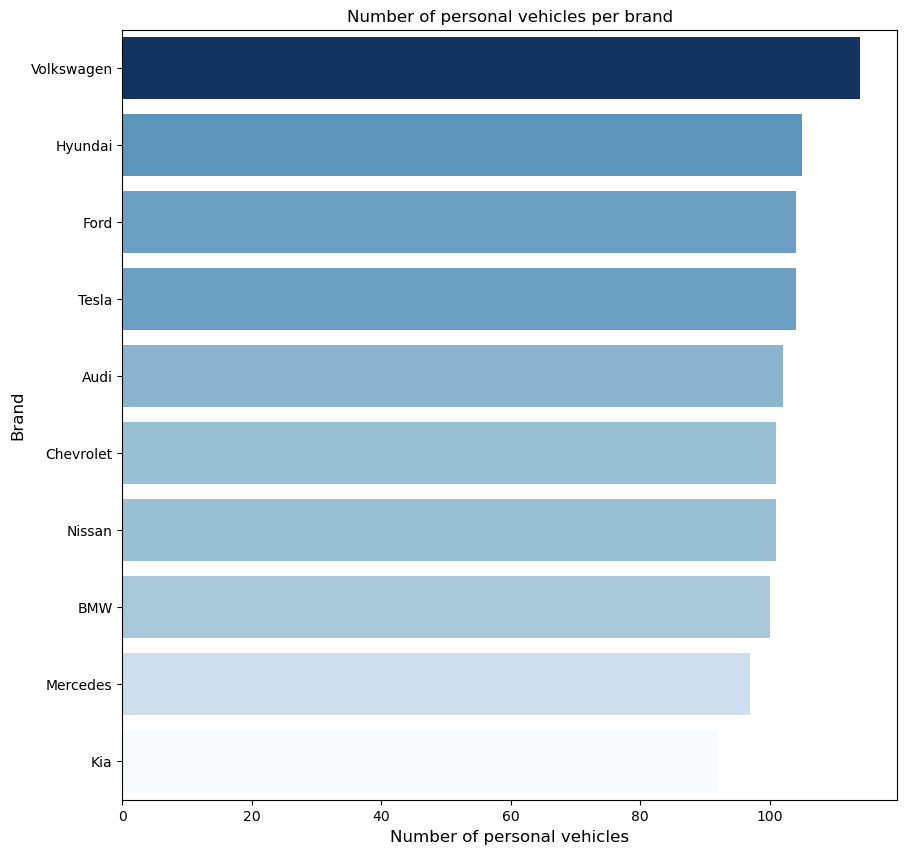

In [277]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Personal_sort, y = Personal_sort['Brand'], x = Personal_sort['Usage_Type'], 
           palette = 'Blues', hue = 'Usage_Type')
plt.xlabel('Number of personal vehicles', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Number of personal vehicles per brand')
plt.show()

## Insights:
- Volkswagen leads in making the most amount of personal vehicles.
- Followed slightly by: Hyundai, Ford and Tesla.
- Audi, Chevrolet, Nissan and BMW produce less personal vehicles.
- Mercedes and Kia produce the least amount of personal vehicles.
## Conclusions:
- There is a great amount of personal vehicles being produced.
- These vehicles aim at a wide audience: specifically the middle class.
- Volkswagen's history with personal vehicles is deep: it started in the 1930s when Adolf Hitler decided to make a plan to extend roads and build bridges, this signified the birth of Volkswagen which means people's (Volks) car (wagen), this car brand is credited in the entry of car culture in the German idenitity to this day.

In [281]:
Compare

,Brand,Vehicle_Type,Usage_Type
0,Nissan,SUV,Personal
1,Nissan,Sedan,Personal
2,Hyundai,SUV,Fleet
3,Audi,Hatchback,Fleet
4,Tesla,Truck,Commercial
...,...,...,...
2995,Mercedes,SUV,Personal
2996,Ford,Hatchback,Fleet
2997,Kia,Truck,Fleet
2998,Mercedes,Truck,Commercial


In [289]:
SQL4 = """SELECT Usage_Type, Brand, COUNT(*) AS Number_of_Fleets_produced FROM Compare
WHERE Usage_Type = 'Fleet'
GROUP BY Brand
ORDER BY Number_of_Fleets_produced DESC"""

In [291]:
Fleet = psql.sqldf(SQL4)

In [293]:
Fleet

,Usage_Type,Brand,Number_of_Fleets_produced
0,Fleet,Chevrolet,106
1,Fleet,Nissan,103
2,Fleet,Audi,103
3,Fleet,Ford,101
4,Fleet,BMW,100
5,Fleet,Kia,98
6,Fleet,Volkswagen,94
7,Fleet,Mercedes,94
8,Fleet,Hyundai,93
9,Fleet,Tesla,92


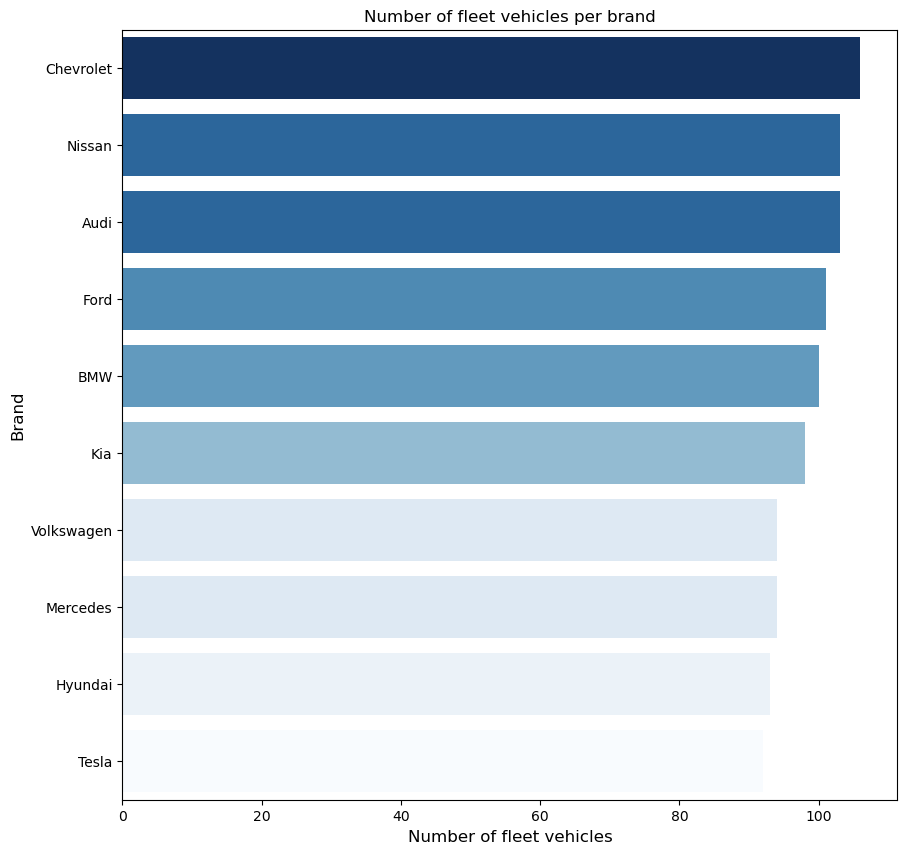

In [295]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Fleet, y = Fleet['Brand'], x = Fleet['Number_of_Fleets_produced'], 
           palette = 'Blues', hue = 'Number_of_Fleets_produced')
plt.xlabel('Number of fleet vehicles', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Number of fleet vehicles per brand')
plt.show()

## Insights:
- Chevrolet leads in making the most amount of fleet vehicles. (A convoy composed of 5 to 6 vehicles)
- Followed by: Nissan, Audi, Ford and BMW.
- Followed by a small amount: Kia.
- Volkswagen, Mercedes, Hyundai and Tesla make the least amount of fleet vehicles.
## Conclusiosn:
- Tesla produce the least amount of fleet vehicles despite being the pionner of electric vehicles: This shows that tesla aims at making prototype vehicles rather than practical and performance based vehicles.
- There's a comparable amount of fleet vehicles being produced, this shows that a lot of companies require this type of vehicle to help them in transporting goods.

In [298]:
SQL5 = """SELECT Usage_Type, Brand, COUNT(*) AS Number_of_Commercials_produced FROM Compare
WHERE Usage_Type = 'Commercial'
GROUP BY Brand
ORDER BY Number_of_Commercials_produced DESC"""

In [300]:
Commercial = psql.sqldf(SQL5)

In [302]:
Commercial

,Usage_Type,Brand,Number_of_Commercials_produced
0,Commercial,Ford,118
1,Commercial,BMW,111
2,Commercial,Mercedes,102
3,Commercial,Chevrolet,101
4,Commercial,Volkswagen,100
5,Commercial,Hyundai,99
6,Commercial,Kia,96
7,Commercial,Nissan,94
8,Commercial,Tesla,91
9,Commercial,Audi,84


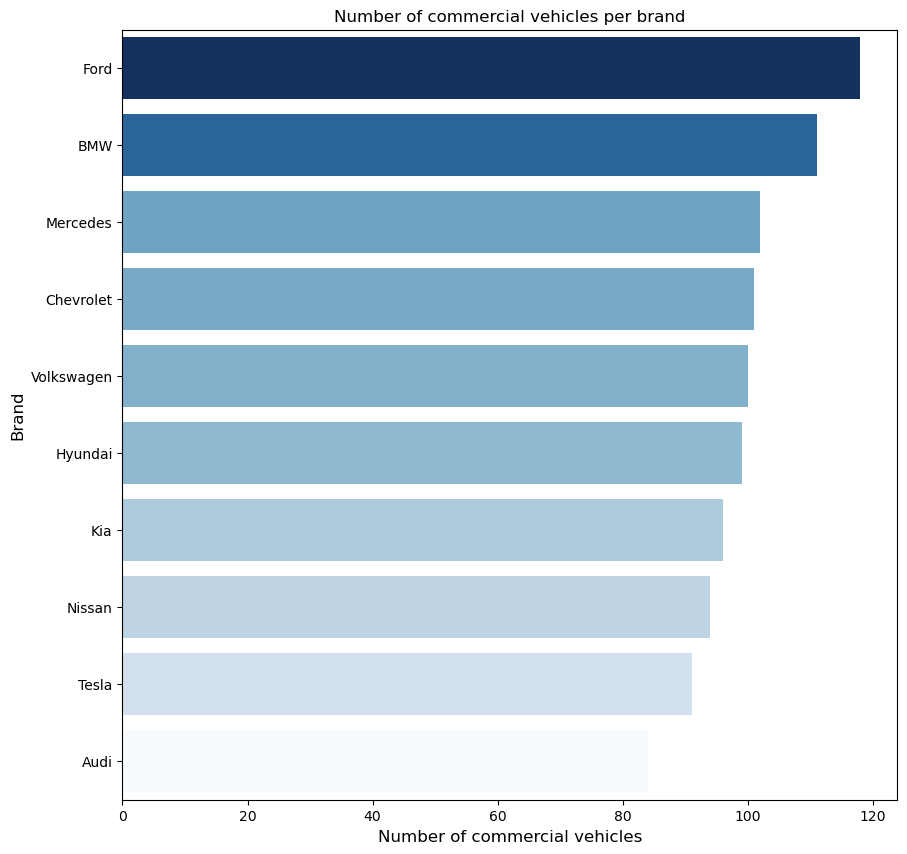

In [306]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Commercial, y = Commercial['Brand'], x = Commercial['Number_of_Commercials_produced'], 
           palette = 'Blues', hue = 'Number_of_Commercials_produced')
plt.xlabel('Number of commercial vehicles', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Number of commercial vehicles per brand')
plt.show()

## Insights:
- Ford and BMW lead in making the most commercial vehicles.
- Followed by Mercedes, Chevrolet, Volkswagen, Hyundai.
- Followed by a lower amount in: Kia, Nissan, Tesla and Audi.
## Conclusions:
- The commercial vehicle is dominated by Ford and BMW.
- Mercedes, Chevrolet, Volkswagen, Hyundai hold a competitive position, showing consistent production levels.
- Kia, Nissan, Tesla and Audi produce the least amount of commerical, they aim more at making luxury and economic vehicles

## Goal 10: Compare brands based on average value

In [316]:
df

,Vehicle_ID,Brand,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,...,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD,Average charging cost
0,1,Nissan,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,...,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483,187.3
1,2,Nissan,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,...,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287,582.2
2,3,Hyundai,2021,North America,SUV,118.5,84.0,677,173.6,0.84,...,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023,206.7
3,4,Audi,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,...,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398,677.2
4,5,Tesla,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,...,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033,494.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Mercedes,2021,North America,SUV,57.2,84.0,239,102.2,0.69,...,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749,148.1
2996,2997,Ford,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,...,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080,217.0
2997,2998,Kia,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,...,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286,7.1
2998,2999,Mercedes,2015,North America,Truck,69.4,98.4,336,94.7,0.90,...,9.34,-7.6,Commercial,24.95,1843,1905,0.20,780.03,19581,105.2


In [345]:
Average_value = df.groupby('Brand')['Resale_Value_USD'].mean().round(1).reset_index()

In [324]:
Average_value

,Brand,Resale_Value_USD
0,Audi,22469.3
1,BMW,22868.4
2,Chevrolet,22230.8
3,Ford,22596.5
4,Hyundai,22342.7
5,Kia,22091.9
6,Mercedes,22621.9
7,Nissan,21874.7
8,Tesla,21840.7
9,Volkswagen,21592.6


In [326]:
Average_value_sorted = Average_value.sort_values(by = 'Resale_Value_USD', ascending = False)

In [328]:
Average_value_sorted

,Brand,Resale_Value_USD
1,BMW,22868.4
6,Mercedes,22621.9
3,Ford,22596.5
0,Audi,22469.3
4,Hyundai,22342.7
2,Chevrolet,22230.8
5,Kia,22091.9
7,Nissan,21874.7
8,Tesla,21840.7
9,Volkswagen,21592.6


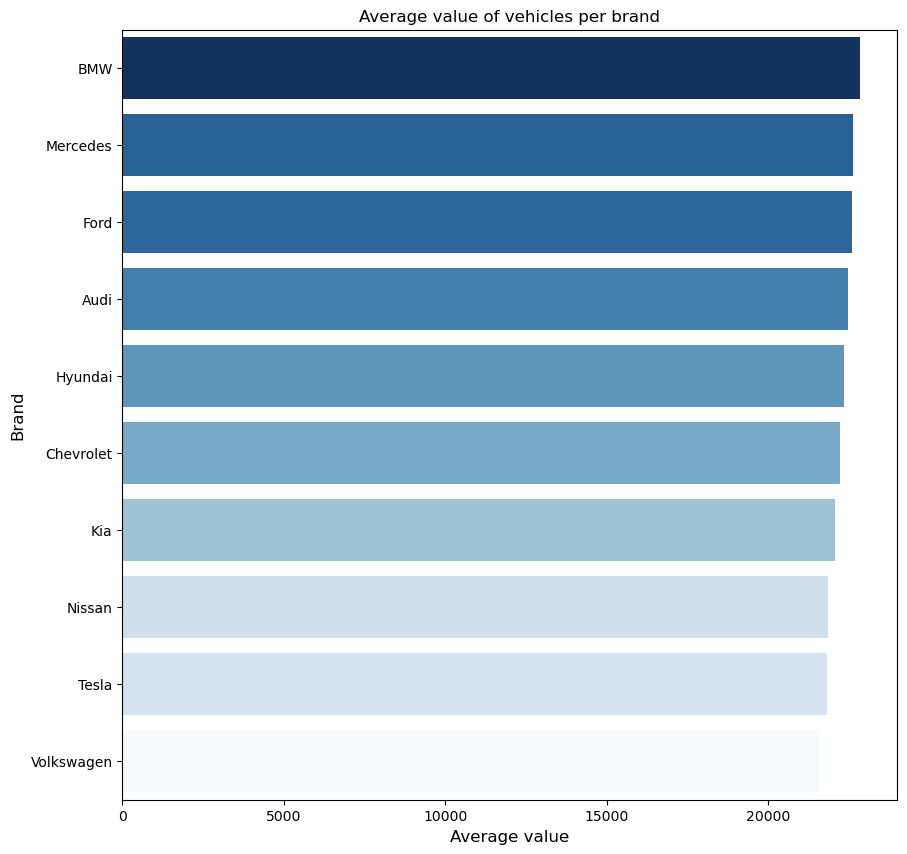

In [338]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Average_value_sorted, y = Average_value_sorted['Brand'], x = Average_value_sorted['Resale_Value_USD'], 
           palette = 'Blues', hue = 'Resale_Value_USD')
plt.xlabel('Average value', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average value of vehicles per brand')
plt.show()

## Insights: 
- BMW, Mercedes, Ford, Audi and Hyundai dominates the electric car market with the best value.
- followed by: chevrolet, Kia.
- followed by a lower margin: Nissan, Tesla and Volkswagen.
## Conclusions:
- This chart shows that the electric car market is growing, there is demand for this type of vehicle in times of enviromental awareness and the high cost of fuel.

In [354]:
Value_region = df.groupby('Region')['Resale_Value_USD'].mean().round(1).reset_index()

In [356]:
Value_region

,Region,Resale_Value_USD
0,Asia,22077.8
1,Australia,21872.3
2,Europe,22529.2
3,North America,22586.3


In [360]:
Value_region1 = Value_region.sort_values(by = 'Resale_Value_USD', ascending = False)

In [362]:
Value_region1

,Region,Resale_Value_USD
3,North America,22586.3
2,Europe,22529.2
0,Asia,22077.8
1,Australia,21872.3


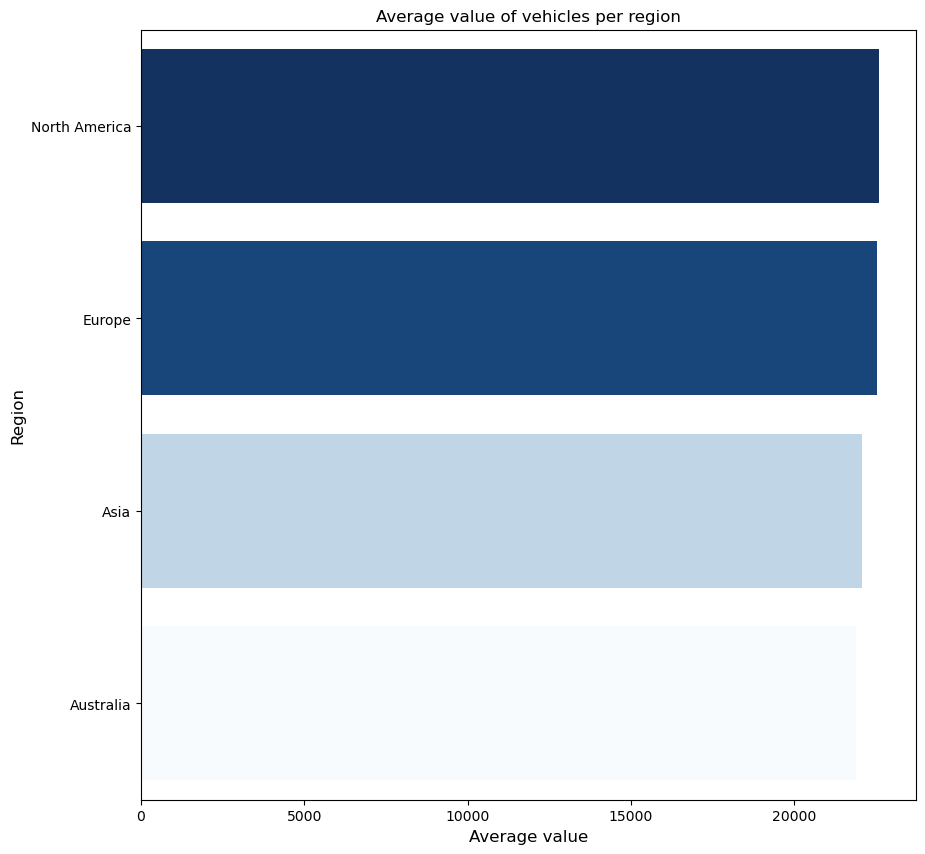

In [364]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Value_region1, y = Value_region1['Region'], x = Value_region1['Resale_Value_USD'], 
           palette = 'Blues', hue = 'Resale_Value_USD')
plt.xlabel('Average value', size = 12)
plt.ylabel('Region', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average value of vehicles per region')
plt.show()

## Insights:
- North America and Europe dominates the electric car market.
- North America has one of the biggest economic unions in the world: USA, a commonwealth of 50 states with a variety of activities.
- Same thing for Europe: the European union which was formed in the 1990s aims at cooperation and trade between countries.
- Followed by Asia, despite not having a big economic union like the USA and the EU, Asia has car powerhorses like Japan, South Korea, China and India.
- Australia has the least value in electric vehicles, due to its nature as a country with too many desert, canyons, forrests and not enough roads to encourage driving.
## Conclusions:
- The electric car market is growing.

## Goal 11: Compare vehicle brands based on protection (maintenance and insurance)

In [368]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Vehicle_ID                        3000 non-null   int64  
 1   Brand                             3000 non-null   object 
 2   Year                              3000 non-null   int64  
 3   Region                            3000 non-null   object 
 4   Vehicle_Type                      3000 non-null   object 
 5   Battery_Capacity_kWh              3000 non-null   float64
 6   Battery_Health_%                  3000 non-null   float64
 7   Range_km                          3000 non-null   int64  
 8   Charging_Power_kW                 3000 non-null   float64
 9   Charging_Time_hr                  3000 non-null   float64
 10  Charge_Cycles                     3000 non-null   int64  
 11  Energy_Consumption_kWh_per_100km  3000 non-null   float64
 12  Mileag

In [371]:
protection = df[['Brand', 'Maintenance_Cost_USD', 'Insurance_Cost_USD']]

In [373]:
protection

,Brand,Maintenance_Cost_USD,Insurance_Cost_USD
0,Nissan,969,843
1,Nissan,1157,1186
2,Hyundai,291,1890
3,Audi,401,2481
4,Tesla,214,2336
...,...,...,...
2995,Mercedes,1645,2357
2996,Ford,289,868
2997,Kia,1013,695
2998,Mercedes,1843,1905


In [425]:
SQL6 = """SELECT Brand, AVG(Maintenance_Cost_USD) as Maintenance_cost FROM protection
GROUP BY Brand
ORDER BY Maintenance_cost DESC"""

In [427]:
protection1 = psql.sqldf(SQL6)

In [429]:
protection1.round(1)

,Brand,Maintenance_cost
0,Audi,1149.1
1,Mercedes,1129.2
2,Tesla,1123.1
3,Volkswagen,1121.9
4,Nissan,1097.7
5,Ford,1097.7
6,BMW,1089.5
7,Chevrolet,1088.8
8,Hyundai,1084.4
9,Kia,1062.4


In [431]:
SQL7 = SQL6 = """SELECT Brand, AVG(Insurance_Cost_USD) as Insurance_cost FROM protection
GROUP BY Brand
ORDER BY Insurance_cost DESC"""

In [433]:
protection2 = psql.sqldf(SQL7)

In [437]:
protection2.round(1)

,Brand,Insurance_cost
0,Ford,1575.2
1,Volkswagen,1532.8
2,Audi,1530.1
3,Mercedes,1500.7
4,BMW,1491.1
5,Chevrolet,1488.5
6,Hyundai,1486.6
7,Tesla,1463.5
8,Nissan,1455.4
9,Kia,1420.2


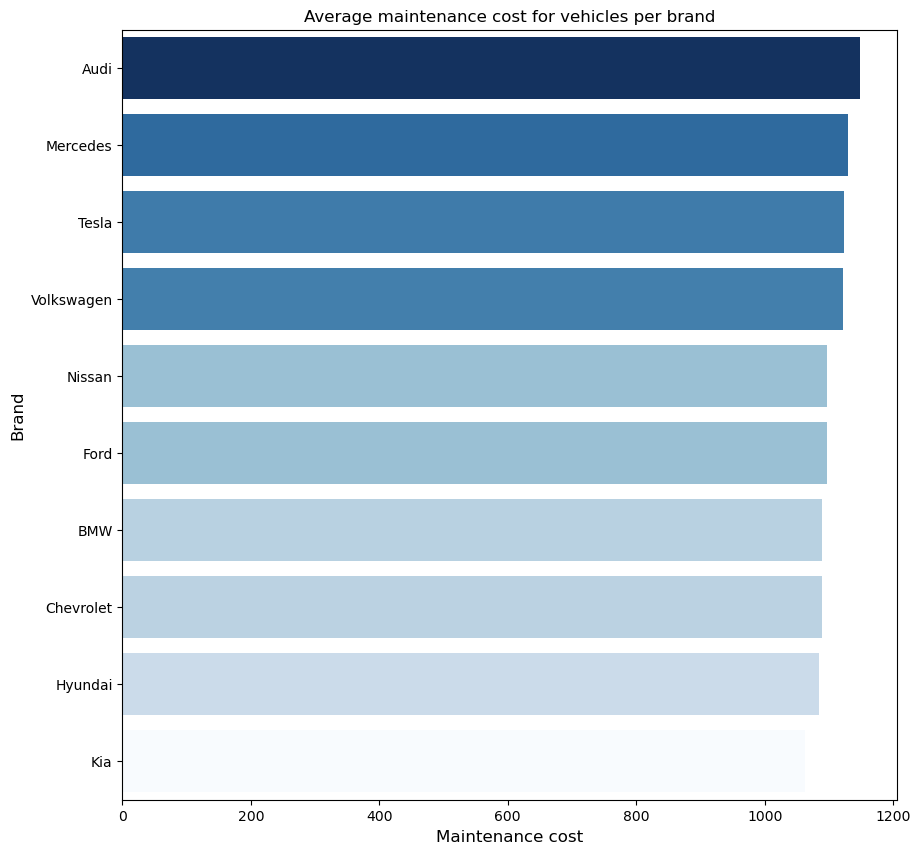

In [441]:
plt.figure(figsize = (10, 10))
sns.barplot(data = protection1, y = protection1['Brand'], x = protection1['Maintenance_cost'], 
           palette = 'Blues', hue = 'Maintenance_cost')
plt.xlabel('Maintenance cost', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average maintenance cost for vehicles per brand')
plt.show()

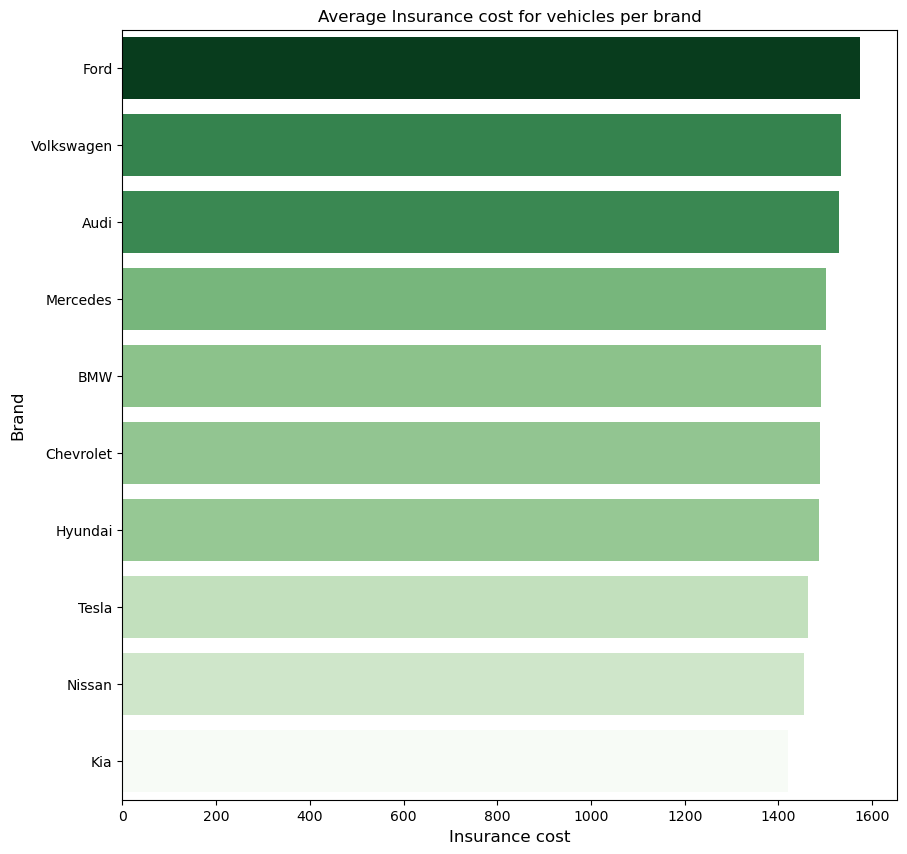

In [443]:
plt.figure(figsize = (10, 10))
sns.barplot(data = protection2, y = protection2['Brand'], x = protection2['Insurance_cost'], 
           palette = 'Greens', hue = 'Insurance_cost')
plt.xlabel('Insurance cost', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average Insurance cost for vehicles per brand')
plt.show()

## Insights:
- Audi has the highest maintenance cost, while it lies in the 3rd place in terms of insurance cost, indicating high insurance cost.
- Ford has the highest insurance cost, While it lies in the 6th place in terms of maintenance cost, indicating cheapter maintenance.
- Tesla has slightly high maintenance cost, while it lies in the 8th place in terms of insurance cost, indicating cheaper insurance.
- Mercedes is in the 2nd place in terms of maintenance cost, indicating high maintenance cost, while it lies in the 4rth place in terms of insurance cost, indicating slightly high insurance cost.
- Volkswagen has high insurance cost (2nd place), While Volkswagen in terms of insurance cost lies in the 4rth place, indicating slightly high insurance cost.
- Kia has the lowest insurance cost and maintenance cost.
## Conclusions:
- Electric vehicles cost high in insurance and maintenance of vehicles, which shows how much effort is made in making these vehicles and repairing them of any damage.